# Vision Transformer (ViT)

### Understanding ViT and the motivation behind ViTAEv2

This notebook first follows an image through a small ViT forward pass, then explains the selected [ViTAEv2 paper](https://doi.org/10.1007/s11263-022-01739-w): the problem it addresses, its architecture, and one experiment supporting a design choice.

**Presentation route:** Sections 1–11 introduce the building blocks. Section 12 explains what the paper changes and why. The PyTorch examples illustrate the foundations; they do not implement ViTAEv2.


## 1. What is ViT?

A **Vision Transformer (ViT)** is an image classification model. Instead of processing the entire image as one input to the Transformer, it first divides the image into small patches. Each patch becomes a token in a sequence.

The main path is **image → patches → embeddings → Transformer encoder → class prediction**. This is similar to a language Transformer receiving a sequence of word tokens, but here the tokens represent image regions.

## 2. Split the image into patches

Imagine a **32 × 32** RGB image divided into **8 × 8** squares. There are 4 patches across and 4 down, so the image produces **16 patches**. Each patch contains **8 × 8 × 3 = 192** pixel values.

Patch size controls the sequence length: smaller patches preserve more detail, but create more tokens and require more attention computation. The code below reshapes an image into its 16 flattened patches.

In [ ]:
import torch
from torch import nn

torch.manual_seed(42)
image = torch.rand(1, 3, 32, 32)  # [batch, RGB channels, height, width]
patches = nn.functional.unfold(image, kernel_size=8, stride=8)
patches = patches.transpose(1, 2)
print("Image:", tuple(image.shape))
print("16 flattened patches:", tuple(patches.shape))  # [1, 16, 192]

## 3. Turn patches into embeddings

A raw patch contains pixel values, while the Transformer operates on vectors of a chosen size. A **learned linear projection** maps every flattened patch to an embedding. In our example, each patch changes from **192 values to 64 values**.

The projection uses the same learned transformation for all patches. Its weights are trained along with the rest of the model, so the embeddings become useful for classification.

In [ ]:
projection = nn.Linear(192, 64)
tokens = projection(patches)
print("Patch embeddings:", tuple(tokens.shape))  # [1, 16, 64]

## 4. Add a CLS token

ViT places an extra learnable **classification token**, called **CLS**, before the patch tokens. It starts as a model parameter, then exchanges information with the image patches through attention.

After the Transformer encoder, the final CLS representation is sent to a classification layer. Our 16 patch tokens therefore become a sequence of **17 tokens**: one CLS token followed by 16 image tokens.

## 5. Add position information

After converting patches into tokens, the Transformer needs to know their original locations. Without position information, shuffling the patch tokens would make it difficult to distinguish different spatial arrangements.

A **position embedding** is added to each token. Its role is simple: patch content describes *what* appears, while position helps describe *where* it appears. The small example below uses learnable position vectors.

In [ ]:
cls_token = nn.Parameter(torch.zeros(1, 1, 64))
position = nn.Parameter(torch.randn(1, 17, 64) * 0.02)
sequence = torch.cat([cls_token.expand(tokens.size(0), -1, -1), tokens], dim=1)
# Small random position vectors distinguish locations before training.
# These parameters have not been trained in this demonstration.
sequence = sequence + position
print("CLS + 16 patches:", tuple(sequence.shape))  # [1, 17, 64]

## 6. Let patches communicate with self-attention

Each token is transformed into three vectors: **Query (Q)**, **Key (K)**, and **Value (V)**. A query is compared with the keys of other tokens. The resulting weights determine how much information to take from their values.

The operation is **Attention(Q, K, V) = softmax(QKᵀ / √d_k) V**. For example, a patch containing part of an object can attend to a distant patch containing another part. Here, d_k is the dimension of a key vector in one head. Attention weights are computed for each input; training learns the projections that produce Q, K, and V.

## 7. Use multi-head attention

A single attention head produces one set of relationships between tokens. **Multi-head attention** learns several such sets in parallel and combines their outputs.

Different heads can focus on different visual relationships, although their roles are learned rather than assigned in advance. The output still has one updated representation for each token.

## 8. Pass tokens through a Transformer block

A ViT encoder block contains **multi-head attention** and a **feed-forward network (MLP)**. Attention exchanges information *between* tokens. The MLP then transforms the representation of *each* token.

**Layer normalization** and **residual connections** help the block train. ViT stacks multiple blocks so that information can be refined repeatedly before classification.

## 9. Make the prediction

Once the tokens pass through the encoder, ViT takes the final **CLS token** and sends it to a linear classification head. If the task has 10 classes, the head returns **10 logits**: one score for each class.

The highest score gives the predicted class. During training, the logits are compared with the correct label to calculate the loss.

## 10. See the full path in code

The following small PyTorch model puts the pieces together. A convolution with kernel size and stride equal to the patch size efficiently performs the patch projection. For each non-overlapping patch, this is equivalent to flattening its pixels and applying the same linear projection. The model then adds CLS and position embeddings, applies two Transformer blocks, and normalizes the final CLS representation, and produces class scores. The blocks use pre-LayerNorm, matching the ordering in the original ViT.

It is initialized with random weights, so the example demonstrates the **forward pass and tensor shapes**, not meaningful image recognition.

In [ ]:
class TinyViT(nn.Module):
    def __init__(self, image_size=32, patch_size=8, dim=64, num_classes=10):
        super().__init__()
        count = (image_size // patch_size) ** 2
        self.patch_embed = nn.Conv2d(3, dim, patch_size, stride=patch_size)
        self.cls = nn.Parameter(torch.zeros(1, 1, dim))
        self.position = nn.Parameter(torch.randn(1, count + 1, dim) * 0.02)
        block = nn.TransformerEncoderLayer(
            d_model=dim, nhead=4, dim_feedforward=dim * 2,
            batch_first=True, norm_first=True, activation="gelu", dropout=0.0
        )
        self.encoder = nn.TransformerEncoder(block, num_layers=2)
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x).flatten(2).transpose(1, 2)
        x = torch.cat([self.cls.expand(x.size(0), -1, -1), x], dim=1)
        x = self.encoder(x + self.position)
        return self.head(self.norm(x[:, 0]))

model = TinyViT().eval()
with torch.no_grad():
    scores = model(image)
print("Input:", tuple(image.shape))
print("Class scores:", tuple(scores.shape))  # [1, 10]

## 11. How does ViT learn?

A training set provides images and correct class labels. For each batch, ViT produces logits; a loss function measures the prediction error. Backpropagation updates the patch projection, position embeddings, CLS token, encoder, and classifier.

ViT learns relationships between patches from data. On smaller datasets, **pretraining** and image-specific architectural choices can be especially useful. The example in this notebook does not train a model or report accuracy.

## 12. The selected paper: from ViT to ViTAEv2

### A. What problem does the paper address?

Self-attention lets ViT connect distant image regions, but the authors argue that it has to learn useful visual priors from data. They focus on **locality** (nearby pixels often form meaningful patterns) and **scale variation** (the same object can appear at different sizes).

An **inductive bias** is an assumption built into the architecture that guides what it learns. For example, a convolution looks at neighboring pixels using a shared filter. Imagine the same dog photographed close up and from far away: useful features should capture both small details and larger structures. The paper introduces local and multi-scale convolutional pathways alongside attention to help with these requirements.

### B. How do the proposed cells work?

| Cell | Main operations | Purpose |
|---|---|---|
| **Reduction Cell (RC)** | PRM → attention, in parallel with PCM; add the two outputs, then apply the feed-forward network | Reduce spatial resolution while extracting multi-scale and local features |
| **Normal Cell (NC)** | Attention in parallel with PCM; add the outputs, then apply the feed-forward network | Refine local and long-range information without reducing spatial resolution |

**PRM — Pyramid Reduction Module:** strided convolutions with different dilation rates collect information from different spatial ranges. Their outputs are concatenated before attention.

**PCM — Parallel Convolutional Module:** a convolutional branch extracts local patterns alongside the attention branch. Their outputs are fused by element-wise addition. NC does not use PRM.

The key idea is to give local-pattern modeling a convolutional pathway while attention models relationships between regions. Merely naming PCM and PRM is not enough: their placement and fusion explain the contribution. See Figure 2 and Section 3.2 of the paper for the cell details.

### C. What changes in ViTAEv2?

ViTAEv2 rearranges RCs and NCs into **four stages**. An RC begins each stage, followed by NCs. Spatial resolution decreases from H/4 to H/8, H/16, and H/32, producing features at multiple resolutions that are useful beyond classification.

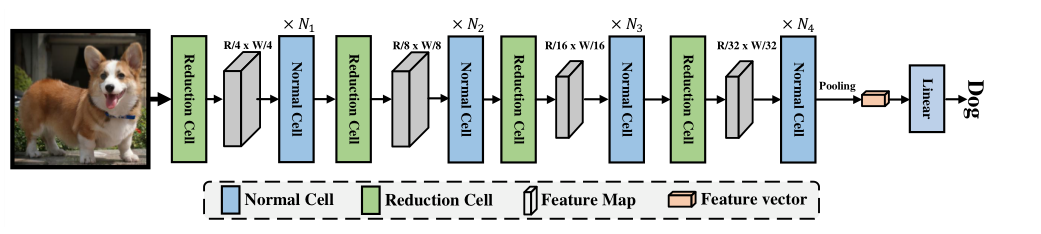

*Source: Zhang et al., ViTAEv2, arXiv:2202.10108v2, Figure 3, page 9. Figure excerpted from the paper.*

The selected stage-wise design uses **window attention in stages 1–2** and **full attention in stages 3–4**. Early feature maps contain many tokens, so restricting attention to windows saves computation. Later maps contain fewer tokens, making full attention more affordable. The convolutional pathways also allow information to cross window boundaries.

**Read the diagram from left to right:** image → four RC/NC stages → pooling → linear classifier. The ViTAEv2 classification path shown here uses pooling; the CLS token in our TinyViT belongs to the introductory ViT example. The original ViTAE design and the stage-wise ViTAEv2 design should not be treated as identical.

### D. What evidence supports this design?

Table 8 compares attention choices with the same parameter count within that experiment. **W** means window attention; **F** means full attention. Top-1 accuracy is measured with 224 × 224 images. The memory column below is training memory with 896 × 896 images and batch size 2 per GPU.

| Attention across the four stages | ImageNet Top-1 accuracy | Training memory at 896 × 896 |
|---|---:|---:|
| W, F, F, F | 82.7% | 34.3 GB |
| **W, W, F, F — selected** | **82.6%** | **15.0 GB** |

The selected design loses **0.1 percentage point** in accuracy while using about **56.3% less memory**, calculated from the rounded table values. This illustrates the accuracy–memory trade-off motivating the choice; it does not prove every ViTAEv2 variant is better under every setting.

The paper also evaluates classification, object detection, segmentation, and animal pose estimation. Those reported results come from trained models, not from the random forward pass above.

### What does our code demonstrate?

TinyViT demonstrates patch embeddings, position information, CLS, encoder blocks, and logits. It contains **no PRM, PCM, or four-stage ViTAEv2 backbone** and does not reproduce the paper's experiments. Understanding its forward pass provides the foundation for explaining what the paper adds.

**For the presentation, be ready to answer:** What visual priors are missing? Where do RC and NC add them? Why did the authors choose W, W, F, F?

### References

1. Zhang et al., [*ViTAEv2: Vision Transformer Advanced by Exploring Inductive Bias for Image Recognition and Beyond*](https://doi.org/10.1007/s11263-022-01739-w). [Paper PDF, arXiv v2](https://arxiv.org/pdf/2202.10108v2).
2. Dosovitskiy et al., [*An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale*](https://arxiv.org/abs/2010.11929).
